In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc

In [2]:
df = pd.read_csv('https://github.com/Explore-AI/Public-Data/blob/master/exports%20ZAR-USD-data.csv?raw=true', index_col=0)

In [3]:
df.head(10)

,ZAR/USD,Value of Exports (ZAR)
2008M01,7.01,39356.82
2008M02,7.66,46946.33
2008M03,7.97,51150.89
2008M04,7.79,56174.34
2008M05,7.62,56240.45
2008M06,7.92,60159.93
2008M07,7.63,61268.16
2008M08,7.66,60390.94
2008M09,8.06,61067.34
2008M10,9.74,65652.57


In [4]:
df.columns = ['Y', 'X']
df.head()

,Y,X
2008M01,7.01,39356.82
2008M02,7.66,46946.33
2008M03,7.97,51150.89
2008M04,7.79,56174.34
2008M05,7.62,56240.45


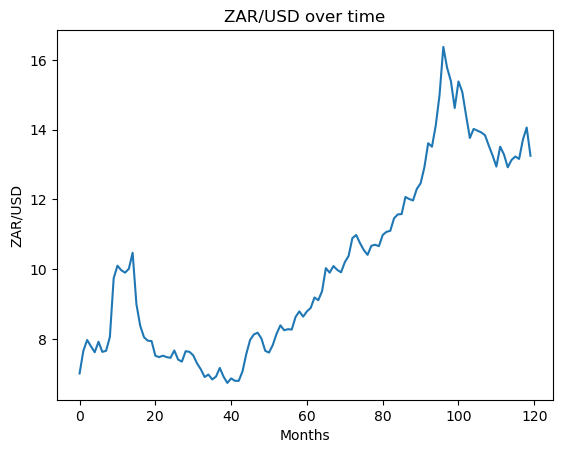

In [5]:
### Plotting the ZAR/USD exchange rate over time
plt.plot(np.arange(len(df.Y)), df.Y)
plt.title("ZAR/USD over time")
plt.xlabel("Months")
plt.ylabel("ZAR/USD")
plt.show()

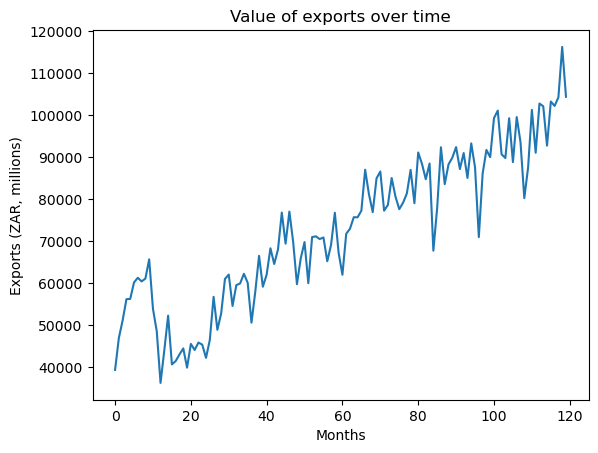

In [6]:
### Plotting the value of exports over time
plt.plot(np.arange(len(df.X)), df.X)
plt.title("Value of exports over time")
plt.xlabel("Months")
plt.ylabel("Exports (ZAR, millions)")
plt.show()

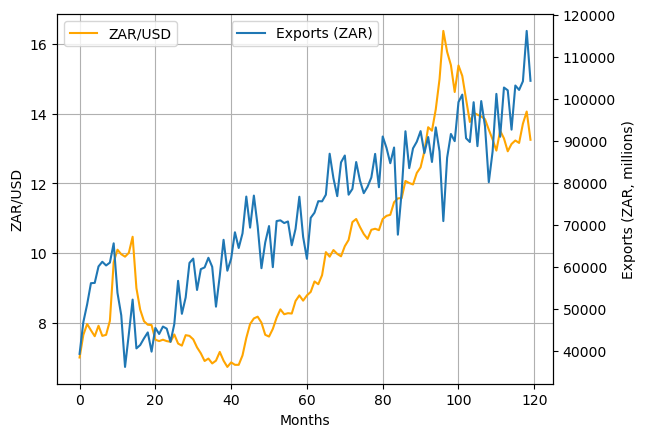

In [7]:
rc('mathtext', default='regular') # Set the default style for math text in plots to regular text
fig = plt.figure()

# Add a subplot to the figure, '111' means 1x1 grid, first subplot
ax = fig.add_subplot(111)

# Plot the ZAR/USD exchange rate data on the primary y-axis using an orange line
ax.plot(np.arange(len(df.Y)), df.Y, '-', label = 'ZAR/USD', color='orange')

# Create a second y-axis (twin of the first) to accommodate another data set on the same x-axis
ax2 = ax.twinx()

# Plot the Value of Exports data on the secondary y-axis
ax2.plot(np.arange(len(df.X)), df.X, '-', label = 'Exports (ZAR)')

# Add legends to distinguish the two lines, with custom locations for clarity
ax.legend(loc=2)  # Legend for the primary axis (ZAR/USD) at the top left (location 2)
ax2.legend(loc=9)  # Legend for the secondary axis (Exports) at the top centre (location 9)

ax.grid() # Enable grid for better readability of the plot

# Set the labels for the x-axis and both y-axes to indicate the data being plotted
ax.set_xlabel("Months")
ax.set_ylabel("ZAR/USD")
ax2.set_ylabel("Exports (ZAR, millions)")

plt.show() 

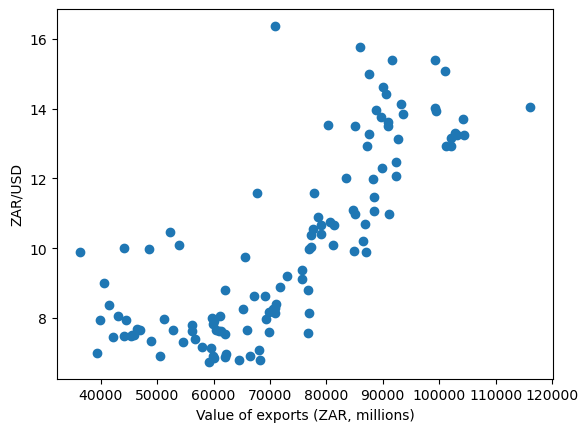

In [8]:
plt.scatter(df['X'], df['Y'])
plt.ylabel("ZAR/USD")
plt.xlabel("Value of exports (ZAR, millions)")
plt.show()

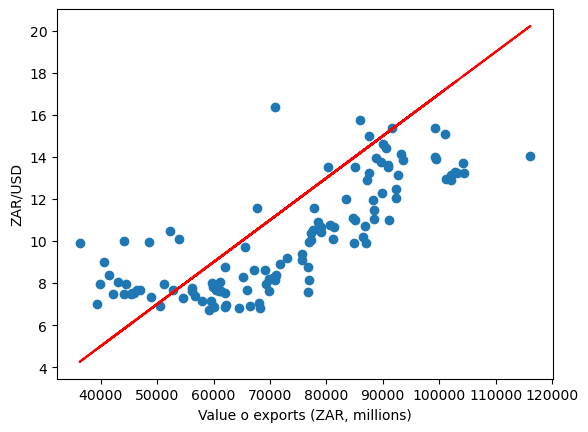

In [9]:
def gen_y(x_list, m, c):
    y_gen = []
    for x_i in x_list:
        y_i = m*x_i + c

        y_gen.append(y_i)

    return(y_gen)

y_gen = gen_y(df.X, 0.0002, -3)

plt.scatter(df.X, df.Y)
plt.plot(df.X, y_gen, color='red')
plt.ylabel("ZAR/USD")
plt.xlabel("Value o exports (ZAR, millions)")
plt.show()

In [10]:
errors = np.array(df.Y - y_gen)
np.round(errors, 2)

array([ 2.14,  1.27,  0.74, -0.44, -0.63, -1.11, -1.62, -1.42, -1.15,
       -0.39,  2.32,  3.26,  5.65,  4.2 ,  3.02,  3.87,  3.09,  2.44,
        2.06,  2.96,  1.41,  1.66,  1.35,  1.41,  2.02,  1.38, -0.94,
        0.57,  0.09, -1.57, -1.88, -0.61, -1.77, -2.07, -2.46, -2.18,
       -0.2 , -1.42, -3.38, -2.09, -2.53, -3.86, -3.11, -3.54, -4.79,
       -2.91, -4.27, -2.78, -0.94, -2.52, -3.34, -1.17, -3.04, -2.84,
       -2.85, -2.89, -1.77, -2.19, -3.56, -1.8 , -0.61, -2.46, -2.4 ,
       -3.03, -2.76, -2.41, -4.49, -3.14, -2.4 , -4.07, -4.11, -2.06,
       -1.83, -3.02, -2.36, -1.97, -2.41, -2.59, -3.69, -2.14, -4.23,
       -3.6 , -2.84, -3.23,  1.03, -0.99, -3.39, -1.7 , -2.68, -2.67,
       -3.01, -1.51, -1.58, -0.49, -1.53,  0.49,  5.18,  1.57,  0.06,
       -0.37, -1.47, -2.13, -0.72, -1.19, -2.83, -0.78, -2.98, -1.86,
        0.5 , -1.24, -4.3 , -1.69, -4.25, -4.49, -2.41, -4.41, -4.27,
       -4.13, -6.18, -4.61])

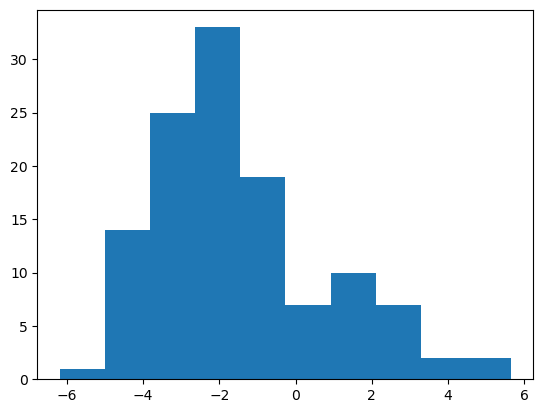

In [11]:
plt.hist(errors)
plt.show()

In [12]:
print("Residual sum of squares:", (errors**2).sum())

Residual sum of squares: 867.1710481532764
